In [1080]:
## Imports

from copy import deepcopy
from datetime import datetime, timedelta
import numpy as np
import random

from stonesoup.types.detection import TrueDetection, Clutter
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity)
from stonesoup.models.measurement.nonlinear import (CartesianToElevationBearingRange, Cartesian2DToBearing)
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.sensor.sensor import SimpleSensor
from stonesoup.models.clutter import ClutterModel
from stonesoup.platform.base import FixedPlatform
from stonesoup.simulator.simple import MultiTargetGroundTruthSimulator
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.plotter import Plotter, Dimension
from itertools import tee
from stonesoup.models.base import ReversibleModel
from stonesoup.tracker.simple import MultiTargetMixtureTracker
from stonesoup.initiator.base import Initiator


In [1081]:
## Simulation params (for manual or automatic tuning)

start_time = datetime.now()
np.random.seed(90)
random.seed(54)
initial_number_targets = 2
birth_rate = 0.08
death_probability = 0.04
num_steps = 20

In [1082]:
## Tuning the sensors accuracy params

radar_ele_nois_std_dev = 0.04
radar_azi_nois_std_dev = 0.04
radar_ran_nois_std_dev = 0.40
rfdoa_azi_nois_std_dev = 0.01

In [1083]:
## Clutter models

radar_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
    (  8_000, 10_000),   # z [m]
)

rfdoa_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
)

radar_clutter_model = ClutterModel(
    clutter_rate = 0.5,
    distribution = np.random.default_rng().uniform,
    dist_params = radar_clutter_params
)

rfdoa_clutter_model = ClutterModel(
    clutter_rate = 0.5,
    distribution = np.random.default_rng().uniform,
    dist_params = rfdoa_clutter_params
)


In [1084]:
## Radar sensor: bearing and range

noise_covar = CovarianceMatrix(np.diag([np.deg2rad(radar_ele_nois_std_dev)**2,np.deg2rad(radar_azi_nois_std_dev)**2, radar_ran_nois_std_dev**2]))

radar = RadarElevationBearingRange(
    ndim_state=6,
    position_mapping=(0, 2, 4),   # [x,vx,y,vy,z,vz]
    noise_covar = noise_covar,
    clutter_model=radar_clutter_model,
)


In [1085]:
## RF-DOA sensor: bearing only

# Cartesian2DToBearing maps 1-D measurement
# noise_covar 1×1

_rfdoa_meas_model = Cartesian2DToBearing(
    ndim_state = 6,
    mapping = (0, 2),                               # x-index, y-index
    noise_covar = np.array([[np.deg2rad(rfdoa_azi_nois_std_dev)**2]]),  # 1×1 covariance
)


class RFDOASensor(SimpleSensor):

    @property
    def measurement_model(self):
        return _rfdoa_meas_model

    def is_detectable(self, state, measurement_model=None):
        return True

    def is_clutter_detectable(self, detection):
        return True

    def measure(self, ground_truths, noise=True, **kwargs):
        detections = set()                           # NOTE: 'detections', not 'detection'

        for truth in ground_truths:
            meas = _rfdoa_meas_model.function(truth, noise=noise)
            detections.add(TrueDetection(
                state_vector = meas,
                groundtruth_path = truth,              # NOTE: correct kwarg name
                timestamp = truth.timestamp,
                measurement_model = _rfdoa_meas_model,
            ))

        if self.clutter_model:
            
            self.clutter_model.measurement_model = _rfdoa_meas_model
            detections |= self.clutter_model.function(ground_truths, **kwargs)

        return detections


rfdoa_sensor = RFDOASensor(clutter_model = rfdoa_clutter_model)

print('RF-DOA sensor:', rfdoa_sensor)
print('measurement_model:', rfdoa_sensor.measurement_model)


RF-DOA sensor: RFDOASensor(
    rotation_offset=None,
    mounting_offset=None,
    movement_controller=None,
    seed=None,
    clutter_model=ClutterModel(
                      clutter_rate=0.5,
                      distribution=<bound method Generator.uniform of Generator(PCG64) at 0x159437CA0>,
                      dist_params=((-10000, 10000), (-10000, 10000)),
                      seed=None))
measurement_model: Cartesian2DToBearing(
    ndim_state=6,
    mapping=(0, 2),
    noise_covar=[[3.0461742e-08]],
    seed=None,
    rotation_offset=StateVector([[0.],
                                 [0.],
                                 [0.]]),
    translation_offset=StateVector([[0.],
                                    [0.]]))


In [1086]:
## Platforms: one fixed platform per sensor, co-located at origin (0,0,0).

platform_state_radar = State(StateVector([[0],[0],[0]]), start_time)
platform_state_rfdoa = State(StateVector([[0],[0],[0]]), start_time)

radar_platform = FixedPlatform(
    states=platform_state_radar,
    position_mapping=(0, 1, 2),
    sensors=[radar],
)

rfdoa_platform = FixedPlatform(
    states=platform_state_rfdoa,
    position_mapping=(0, 1, 2),
    sensors=[rfdoa_sensor],
)

print('Radar platform sensors :', [type(s).__name__ for s in radar_platform.sensors])
print('RFDOA platform sensors :', [type(s).__name__ for s in rfdoa_platform.sensors])


Radar platform sensors : ['RadarElevationBearingRange']
RFDOA platform sensors : ['RFDOASensor']


In [1087]:
## Ground truth simulator

# State layout: [x, vx, y, vy, z, vz]
# Targets start near (0, 0, 2000 m).

transition_model = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(0.5),
    ConstantVelocity(0.5),
    ConstantVelocity(0.1),
])

initial_target_state = GaussianState(
    state_vector=StateVector([[0],[0],[0],[0],[2000],[0]]),
    covar=CovarianceMatrix(np.diag([2000, 50, 2000, 50, 100, 1])),
)

gt_simulator = MultiTargetGroundTruthSimulator(
    transition_model = transition_model,
    initial_state = initial_target_state,
    timestep = timedelta(seconds = 1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)


In [1088]:
## Detection simulators

# One PlatformDetectionSimulator per sensor

gt_sims = tee(gt_simulator, 2)

radar_sim = PlatformDetectionSimulator(
    groundtruth=gt_sims[0],
    platforms=[radar_platform],
)

#radar_plotting, radar_detector = tee(radar_sim, 2)

rfdoa_sim = PlatformDetectionSimulator(
    groundtruth=gt_sims[1],
    platforms=[rfdoa_platform],
)

#rfdoa_plotting, rfdoa_detector = tee(rfdoa_sim, 2)


radar_plotting, radar_detector, radar_for_combined = tee(radar_sim, 3)
rfdoa_plotting, rfdoa_detector, rfdoa_for_combined = tee(rfdoa_sim, 3)


In [1089]:
## Collect detections and truths for plotting



radar_detections = set()
rfdoa_detections = set()
truths           = set()

for (time, r_dets), (_, rf_dets) in zip(radar_plotting, rfdoa_plotting):
    truths.update(gt_simulator.groundtruth_paths)
    radar_detections.update(r_dets)
    rfdoa_detections.update(rf_dets)

# Separate true detections from clutter within each set

radar_true    = {d for d in radar_detections  if isinstance(d, TrueDetection)}
radar_clutter = {d for d in radar_detections  if isinstance(d, Clutter)}
rfdoa_true    = {d for d in rfdoa_detections  if isinstance(d, TrueDetection)}
rfdoa_clutter = {d for d in rfdoa_detections  if isinstance(d, Clutter)}

print(f'Ground truth paths  : {len(truths)}')
print(f'Radar  true dets    : {len(radar_true)}')
print(f'Radar  clutter      : {len(radar_clutter)}')
print(f'RFDOA  true dets    : {len(rfdoa_true)}')
print(f'RFDOA  clutter      : {len(rfdoa_clutter)}')


Ground truth paths  : 2
Radar  true dets    : 40
Radar  clutter      : 10
RFDOA  true dets    : 40
RFDOA  clutter      : 8


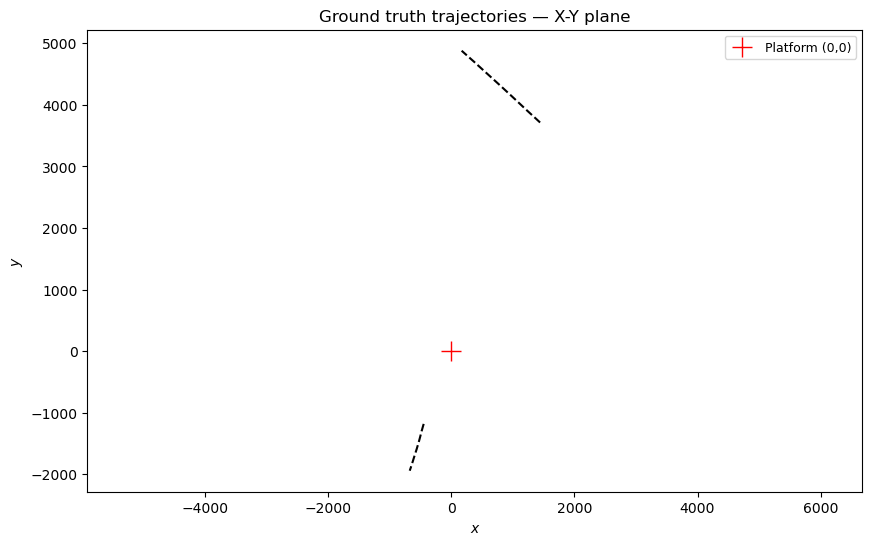

In [1090]:
## Plot: Ground truth only

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 2], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Platform (0,0)')
plotter_gt.ax.set_title('Ground truth trajectories — X-Y plane')
plotter_gt.ax.legend(loc='upper right', fontsize=9)

from IPython.display import display

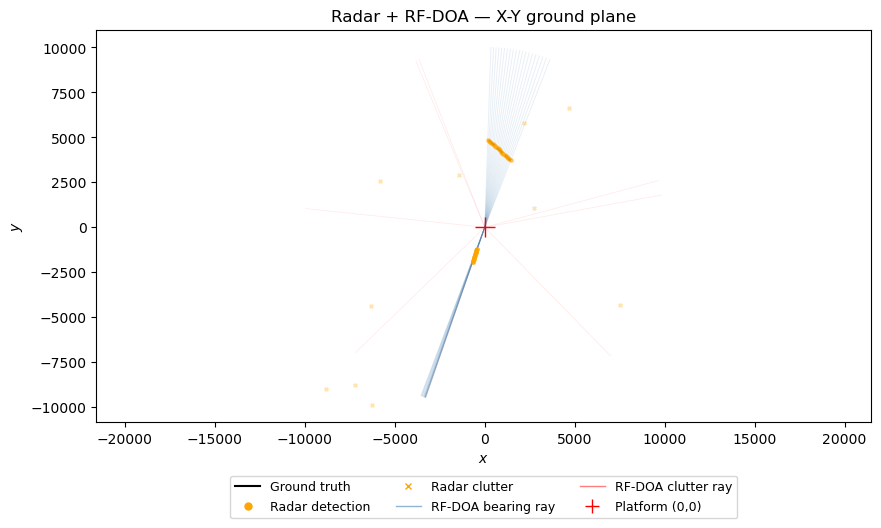

In [1091]:
## Plot: Stone Soup Plotter (2-D, X-Y plane)

# Radar detections are in measurement space (elevation, bearing, range).
# plot_measurements() needs Cartesian indices — but radar detections
# are in spherical coords, so the Stone Soup plotter is used only for
# ground truths and RFDOA, and add radar points manually after converting.

# RF-DOA detections are bearing-only: by a ray from the platform
# origin in the measured direction (length = 10 km) to visualise them.

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Stone Soup plotter for ground truths
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')

# ── Radar detections: convert (el, bearing, range) → (x, y) and overlay
def spherical_to_xy(det):
    sv = det.state_vector
    el, az, r = float(sv[0]), float(sv[1]), float(sv[2])
    x = r * np.cos(el) * np.cos(az)
    y = r * np.cos(el) * np.sin(az)
    return x, y

if radar_true:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_true])
    plotter.ax.scatter(rxs, rys, s=6, c='orange', alpha=0.5,
                       zorder=3, label='Radar detections')

if radar_clutter:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_clutter])
    plotter.ax.scatter(cxs, cys, s=6, c='orange', marker='x', alpha=0.3,
                       label='Radar clutter')

# ── RF-DOA: draw bearing rays from origin
RAY_LEN = 10_000   # arbitrary display length [m]

for det in rfdoa_true:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='steelblue', alpha=0.12, linewidth=0.7)

for det in rfdoa_clutter:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='red', alpha=0.08, linewidth=0.6)

# ── Platform marker
plotter.ax.plot(0, 0, 'r+', markersize=14, zorder=5)

# ── Legend
legend_elems = [
    Line2D([0],[0], color='black',     lw=1.5,              label='Ground truth'),
    Line2D([0],[0], color='orange',    lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0],[0], color='orange',    lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0],[0], color='steelblue', lw=1, alpha=0.6,     label='RF-DOA bearing ray'),
    Line2D([0],[0], color='red',       lw=1, alpha=0.5,     label='RF-DOA clutter ray'),
    Line2D([0],[0], color='red',     lw=0, marker='+', ms=10, label='Platform (0,0)'),
]
# put legend below plot like reference notebook
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(handles=legend_elems, loc='upper center',
                  bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)
plotter.ax.set_title('Radar + RF-DOA — X-Y ground plane')

from IPython.display import display


In [1092]:
## Unic data stream (radar + rfdoa) 

from stonesoup.feeder.multi import MultiDataFeeder

combined_detector = MultiDataFeeder([radar_for_combined, rfdoa_for_combined])
combined_plot, combined_tracker_input = tee(combined_detector, 2)

In [1093]:
combined_detections = set()
truths_combined = set()

for time, dets in combined_plot:
    truths_combined.update(gt_simulator.groundtruth_paths)
    combined_detections.update(dets)

combined_true    = {d for d in combined_detections if isinstance(d, TrueDetection)}
combined_clutter = {d for d in combined_detections if isinstance(d, Clutter)}

print(f'Combined true dets : {len(combined_true)}')
print(f'Combined clutter   : {len(combined_clutter)}')

Combined true dets : 80
Combined clutter   : 18


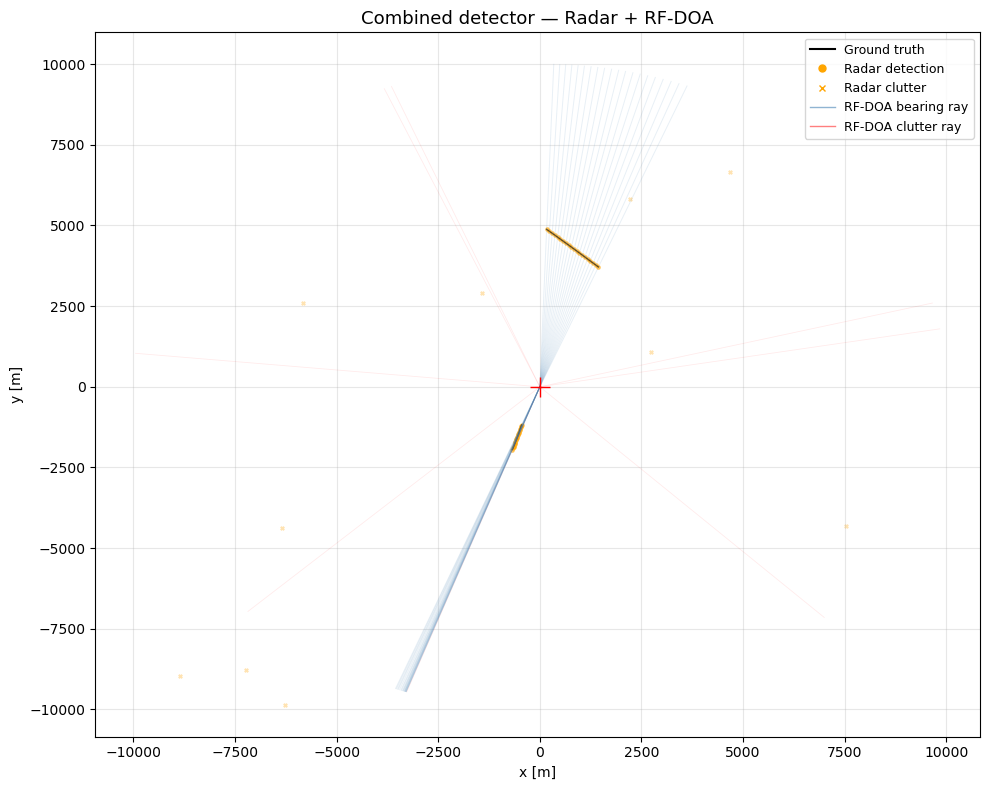

In [1094]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Combined detector — Radar + RF-DOA', fontsize=13)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

# Ground truth
for path in truths_combined:
    xs = [s.state_vector[0, 0] for s in path.states]
    ys = [s.state_vector[2, 0] for s in path.states]
    ax.plot(xs, ys, 'k-', linewidth=1, alpha=0.6)

# Radar: converti (el, bearing, range) → (x, y)
radar_c = {d for d in combined_true    if isinstance(d.measurement_model, CartesianToElevationBearingRange)}
rfdoa_c = {d for d in combined_true    if isinstance(d.measurement_model, Cartesian2DToBearing)}
radar_cl = {d for d in combined_clutter if isinstance(d.measurement_model, CartesianToElevationBearingRange)}
rfdoa_cl = {d for d in combined_clutter if isinstance(d.measurement_model, Cartesian2DToBearing)}

if radar_c:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_c])
    ax.scatter(rxs, rys, s=6, c='orange', alpha=0.5, label='Radar detections')

if radar_cl:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_cl])
    ax.scatter(cxs, cys, s=6, c='orange', marker='x', alpha=0.3, label='Radar clutter')

# RF-DOA: bearing rays
RAY_LEN = 10_000
for det in rfdoa_c:
    b = float(det.state_vector[0])
    ax.plot([0, RAY_LEN*np.cos(b)], [0, RAY_LEN*np.sin(b)],
            color='steelblue', alpha=0.12, linewidth=0.7)

for det in rfdoa_cl:
    b = float(det.state_vector[0])
    ax.plot([0, RAY_LEN*np.cos(b)], [0, RAY_LEN*np.sin(b)],
            color='red', alpha=0.08, linewidth=0.6)

# Platform
ax.plot(0, 0, 'r+', markersize=14, zorder=5)

legend_elems = [
    Line2D([0],[0], color='black',     lw=1.5,               label='Ground truth'),
    Line2D([0],[0], color='orange',    lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0],[0], color='orange',    lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0],[0], color='steelblue', lw=1, alpha=0.6,      label='RF-DOA bearing ray'),
    Line2D([0],[0], color='red',       lw=1, alpha=0.5,      label='RF-DOA clutter ray'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1095]:
## Setup the tracking algorithm

from stonesoup.predictor.kalman import UnscentedKalmanPredictor
from stonesoup.updater.kalman import UnscentedKalmanUpdater


# Extended Kalman Predictor
predictor = UnscentedKalmanPredictor(transition_model)


# Extended Kalman Updater
meas_covar = np.diag([np.deg2rad(0.5), np.deg2rad(0.15), 25])
meas_covar_trk = CovarianceMatrix(1.0*np.power(meas_covar, 2))
meas_model = CartesianToElevationBearingRange(
    
    ndim_state=6,
    mapping=(0, 2, 4),
    noise_covar=meas_covar_trk
)

updater = UnscentedKalmanUpdater(measurement_model=meas_model)

In [1096]:
## Data Association

from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDA

# Hypothesiser
Pd = 0.95  # 95% chance to measure any given target at any given timestep.
hypothesiser = PDAHypothesiser(predictor=predictor,
                               updater=updater,
                               clutter_spatial_density=1e-9,
                               prob_detect=Pd)

data_associator = JPDA(hypothesiser=hypothesiser)

In [1097]:
## Delete tracks if no measurements have fallen within the JPDA gating region in 3 time steps.

from stonesoup.deleter.time import UpdateTimeStepsDeleter
deleter = UpdateTimeStepsDeleter(time_steps_since_update=3)


In [1098]:
## Initiator

from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.dataassociator.neighbour import NearestNeighbour

class ReversibleMultiMeasurementInitiator(MultiMeasurementInitiator):
    
    def initiate(self, detections, timestamp, **kwargs):
        
        # Only consider detections from sensors with reversible models
        #for track initiation. Non-reversible (bearing-only) will still be used for updates.
        
        valid_detections = {
            det for det in detections
            if isinstance(det.measurement_model, ReversibleModel)
        }
        return super().initiate(valid_detections, timestamp, **kwargs)

min_detections = 3  # number of detections required to begin a track

initiator_prior_state = GaussianState(
    state_vector=np.array([[0], [0], [0], [0], [0], [0]]),covar=np.diag([1, 50, 1, 50, 1, 50])**2
)

initiator_meas_model = CartesianToElevationBearingRange(
    ndim_state = 6,
    mapping = np.array([0, 2, 4]),
    noise_covar = noise_covar
)

initiator = ReversibleMultiMeasurementInitiator(
    prior_state = initiator_prior_state,
    measurement_model = initiator_meas_model,
    deleter = deleter,
    data_associator = NearestNeighbour(hypothesiser),
    updater = updater,
    min_points = min_detections,
    updates_only = True
)

In [1099]:
## JPDA Multi-target Tracker

JPDA_tracker = MultiTargetMixtureTracker(
    initiator = initiator,
    deleter = deleter,
    detector = combined_tracker_input,
    data_associator = data_associator,
    updater = updater
)

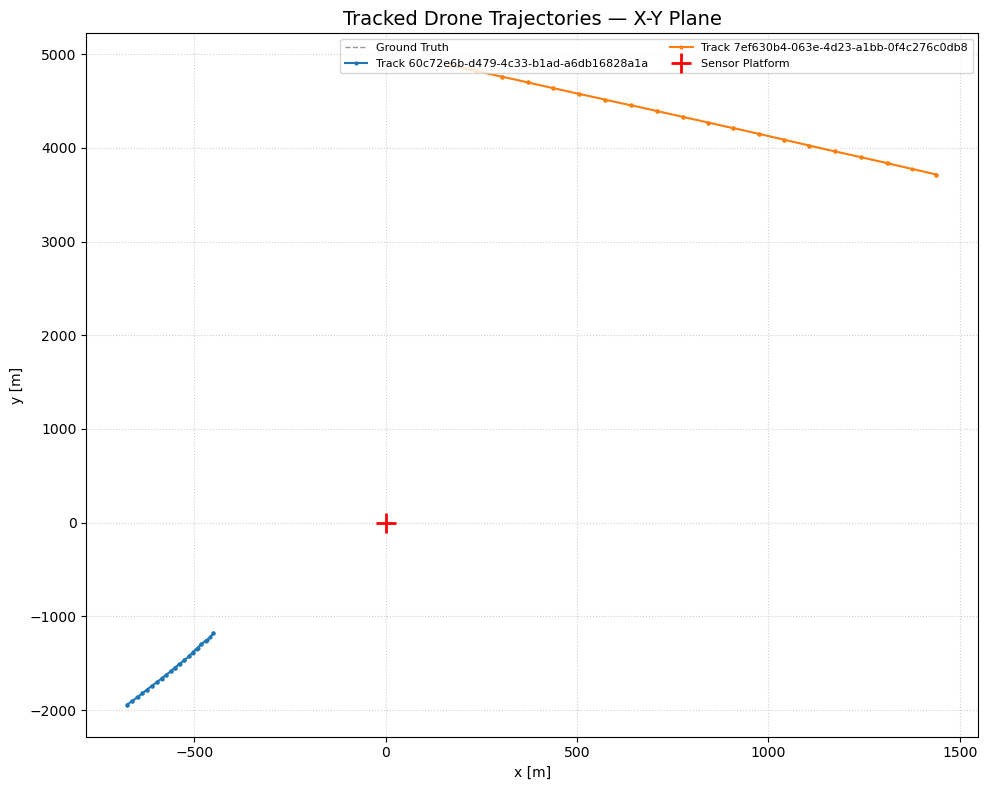

Text(0.5, 0, 'Z [m]')

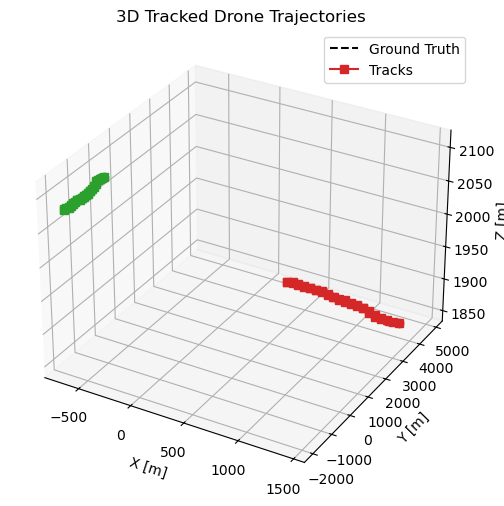

In [1100]:
## Tracking Loop
tracks_plot = set()
groundtruth_plot = set()

for time, ctracks in JPDA_tracker:
    tracks_plot.update(ctracks)
    groundtruth_plot.update(gt_simulator.groundtruth_paths)

## 2D Plotting (X-Y plane)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig2d, ax2d = plt.subplots(figsize=(10, 8))
ax2d.set_title('Tracked Drone Trajectories — X-Y Plane', fontsize=14)
ax2d.set_xlabel('x [m]')
ax2d.set_ylabel('y [m]')

# Plot Ground Truths
for path in groundtruth_plot:
    xs = [s.state_vector[0, 0] for s in path.states]
    ys = [s.state_vector[2, 0] for s in path.states]
    ax2d.plot(xs, ys, 'k--', linewidth=1, alpha=0.4, label='Ground Truth' if path == list(groundtruth_plot)[0] else "")

# Plot Tracks
track_colors = plt.cm.jet(np.linspace(0, 1, len(tracks_plot)))
for i, track in enumerate(tracks_plot):
    txs = [s.state_vector[0, 0] for s in track.states]
    tys = [s.state_vector[2, 0] for s in track.states]
    ax2d.plot(txs, tys, marker='.', markersize=4, linewidth=1.5, label=f'Track {track.id}')

ax2d.plot(0, 0, 'r+', markersize=15, markeredgewidth=2, label='Sensor Platform')
ax2d.grid(True, linestyle=':', alpha=0.6)
ax2d.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 3D Plotting
from stonesoup.plotter import Plotter, Dimension
plotter3d = Plotter(Dimension.THREE)
plotter3d.plot_ground_truths(groundtruth_plot, [0, 2, 4])
plotter3d.plot_tracks(tracks_plot, [0, 2, 4], uncertainty=False, err_freq=5)
plotter3d.ax.set_title('3D Tracked Drone Trajectories')
plotter3d.ax.set_xlabel('X [m]')
plotter3d.ax.set_ylabel('Y [m]')
plotter3d.ax.set_zlabel('Z [m]')